Epoch 1/50
6/6 [==============================] - 1s 3ms/step - loss: 0.3158
Epoch 2/50
6/6 [==============================] - 0s 3ms/step - loss: 0.2077
Epoch 3/50
6/6 [==============================] - 0s 3ms/step - loss: 0.1289
Epoch 4/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0719
Epoch 5/50
6/6 [==============================] - 0s 5ms/step - loss: 0.0335
Epoch 6/50
6/6 [==============================] - 0s 4ms/step - loss: 0.0155
Epoch 7/50
6/6 [==============================] - 0s 4ms/step - loss: 0.0154
Epoch 8/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0172
Epoch 9/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0147
Epoch 10/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0125
Epoch 11/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0120
Epoch 12/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0113
Epoch 13/50
6/6 [==============================] - 0s 4ms/step - loss: 0.

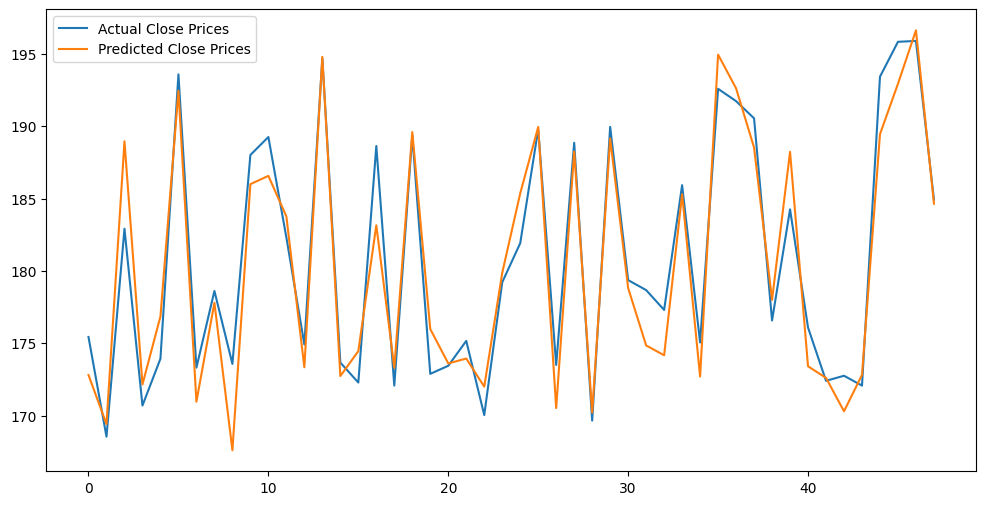

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Load your dataset
data = pd.read_csv("AAPL.csv")  # Replace with your actual CSV file

# Use only the 'close' column
data = data[['Close']]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Function to create sequences for the GRU model


def create_sequences(data, time_steps):
    x, y = [], []
    for i in range(len(data) - time_steps):
        x.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(x), np.array(y)


# Define the time steps and create sequences
time_steps = 10  # Adjust as needed
x, y = create_sequences(data_scaled, time_steps)

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

# Reshape the data for input to GRU
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)

# Build the GRU model
model = Sequential()
model.add(GRU(units=50, activation='relu', input_shape=(x_train.shape[1], 1)))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, epochs=50, batch_size=32)

# Make predictions on the test set
predictions = model.predict(x_test)

# Inverse transform the predictions and actual values
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(np.array([y_test]).reshape(-1, 1))

# Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Plot the actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Close Prices')
plt.plot(predictions, label='Predicted Close Prices')
plt.legend()
plt.show()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.model_selection import train_test_split

# Load your dataset
data = pd.read_csv("AAPL.csv")  # Replace with your actual CSV file

# Use only the 'close' column
data = data[['Close']]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Function to create sequences for the GRU model


def create_sequences(data, time_steps):
    x, y = [], []
    for i in range(len(data) - time_steps):
        x.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(x), np.array(y)


# Define the time steps and create sequences
time_steps = 10  # Adjust as needed
x, y = create_sequences(data_scaled, time_steps)

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

# Reshape the data for input to GRU
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)

# Build the GRU model
model = Sequential()
model.add(GRU(units=50, activation='relu', input_shape=(x_train.shape[1], 1)))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, epochs=50, batch_size=32)

# Use the last 'time_steps' data points to predict the next values
future_sequence = data_scaled[-time_steps:].reshape(1, time_steps, 1)

# Number of future values to predict
num_predictions = 10  # Adjust as needed

Epoch 1/50
6/6 [==============================] - 1s 3ms/step - loss: 0.2590
Epoch 2/50
6/6 [==============================] - 0s 3ms/step - loss: 0.1704
Epoch 3/50
6/6 [==============================] - 0s 3ms/step - loss: 0.1021
Epoch 4/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0506
Epoch 5/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0210
Epoch 6/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0127
Epoch 7/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0153
Epoch 8/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0140
Epoch 9/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0122
Epoch 10/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0119
Epoch 11/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0113
Epoch 12/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0107
Epoch 13/50
6/6 [==============================] - 0s 3ms/step - loss: 0.

1/1 [==============================] - 0s 19ms/step
Future Predictions:
[169.99048 170.27135 170.54198 170.80093 171.04768 171.28358 171.50902
 171.72491 171.93074 172.12791]


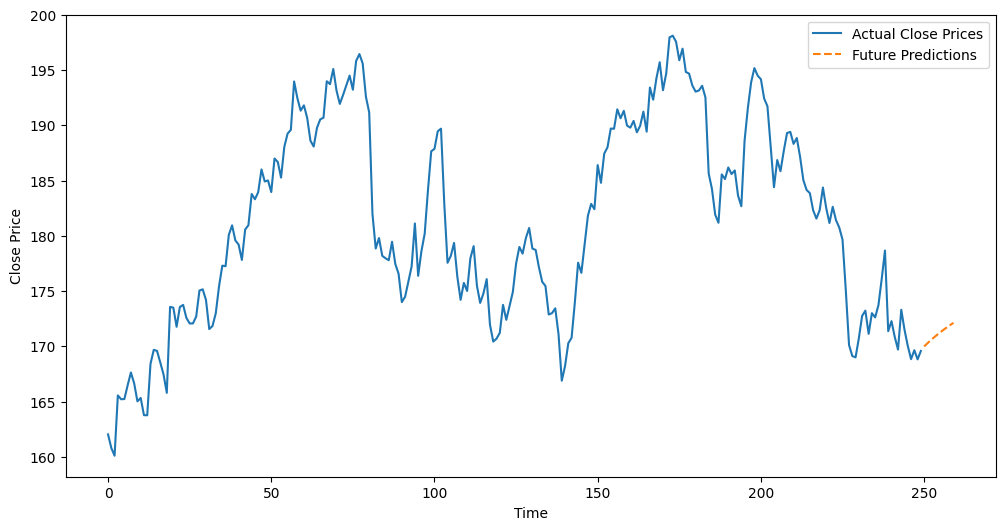

In [5]:
# Make predictions for the next 'num_predictions' values
future_predictions = []

for _ in range(num_predictions):
    next_prediction = model.predict(future_sequence)
    future_predictions.append(next_prediction[0, 0])
    future_sequence = np.append(future_sequence[:, 1:, :], np.array(
        [[next_prediction[0, 0]]]).reshape(1, 1, 1), axis=1)

# Inverse transform the future predictions
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1))

# Display the future predictions
print("Future Predictions:")
print(future_predictions.flatten())

# Plot the entire time series along with future predictions
plt.figure(figsize=(12, 6))
plt.plot(data.index, scaler.inverse_transform(
    data_scaled), label='Actual Close Prices')
future_index = range(len(data_scaled), len(data_scaled) + num_predictions)
plt.plot(future_index, future_predictions,
         label='Future Predictions', linestyle='dashed')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [6]:
from sklearn.metrics import mean_squared_error

# Assuming you have the actual values for the future period in 'actual_future_values'
# Replace 'actual_future_values' with your actual future prices
actual_future_values = data_scaled[-num_predictions:]

# Calculate Mean Squared Error
mse = mean_squared_error(actual_future_values, future_predictions.flatten())
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 29190.369970574015


Epoch 1/50
6/6 [==============================] - 1s 3ms/step - loss: 0.2850
Epoch 2/50
6/6 [==============================] - 0s 3ms/step - loss: 0.2200
Epoch 3/50
6/6 [==============================] - 0s 3ms/step - loss: 0.1642
Epoch 4/50
6/6 [==============================] - 0s 4ms/step - loss: 0.1074
Epoch 5/50
6/6 [==============================] - 0s 4ms/step - loss: 0.0571
Epoch 6/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0204
Epoch 7/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0168
Epoch 8/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0154
Epoch 9/50
6/6 [==============================] - 0s 10ms/step - loss: 0.0130
Epoch 10/50
6/6 [==============================] - 0s 6ms/step - loss: 0.0127
Epoch 11/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0120
Epoch 12/50
6/6 [==============================] - 0s 3ms/step - loss: 0.0121
Epoch 13/50
6/6 [==============================] - 0s 4ms/step - loss: 0

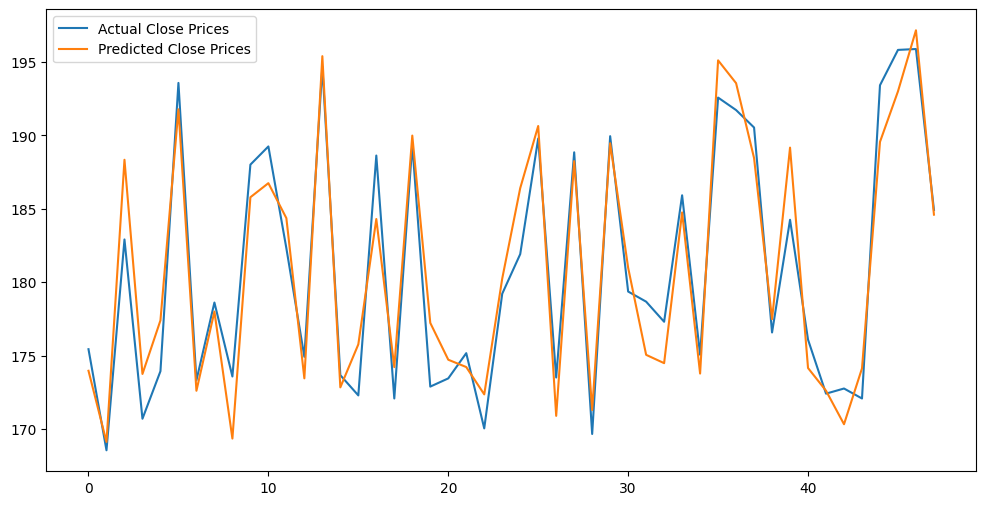

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Load your dataset
data = pd.read_csv("AAPL.csv")  # Replace with your actual CSV file

# Use only the 'close' column
data = data[['Close']]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Function to create sequences for the LSTM model


def create_sequences(data, time_steps):
    x, y = [], []
    for i in range(len(data) - time_steps):
        x.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(x), np.array(y)


# Define the time steps and create sequences
time_steps = 10  # Adjust as needed
x, y = create_sequences(data_scaled, time_steps)

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

# Reshape the data for input to LSTM
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(x_train.shape[1], 1)))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, epochs=50, batch_size=32)

# Make predictions on the test set
predictions = model.predict(x_test)

# Inverse transform the predictions and actual values
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(np.array([y_test]).reshape(-1, 1))

# Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Plot the actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Close Prices')
plt.plot(predictions, label='Predicted Close Prices')
plt.legend()
plt.show()

2/2 [==============================] - 0s 4ms/step
LSTM Root Mean Squared Error (RMSE): 2.471447141700037
GRU Root Mean Squared Error (RMSE): 2.4575409698198163


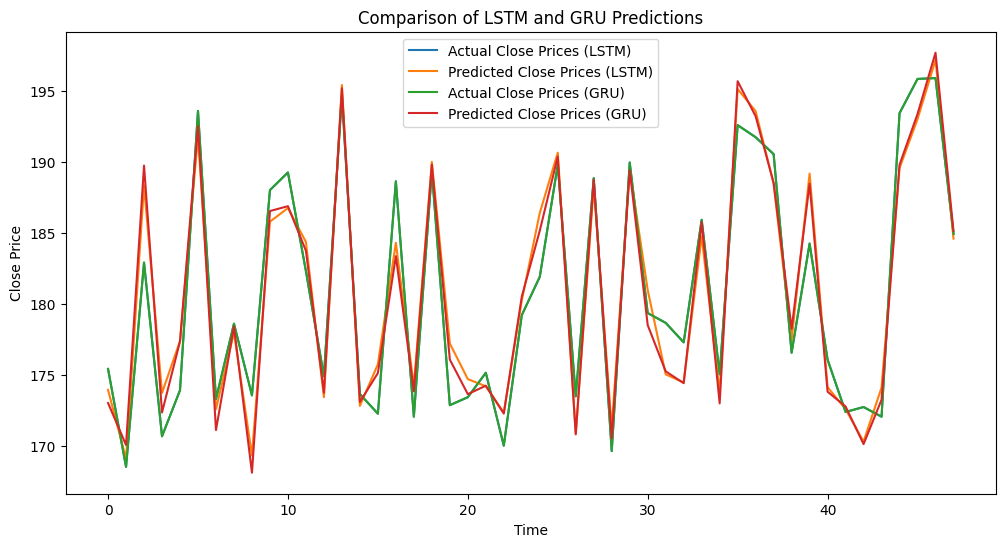

In [10]:
# Create sequences for GRU
x_gru, y_gru = create_sequences(data_scaled, time_steps)

# Split the data into training and testing sets for GRU
x_train_gru, x_test_gru, y_train_gru, y_test_gru = train_test_split(
    x_gru, y_gru, test_size=0.2, random_state=42)

# Reshape the data for input to GRU
x_train_gru = x_train_gru.reshape(
    x_train_gru.shape[0], x_train_gru.shape[1], 1)
x_test_gru = x_test_gru.reshape(x_test_gru.shape[0], x_test_gru.shape[1], 1)

# Build the GRU model
model_gru = Sequential()
model_gru.add(GRU(units=50, activation='relu',
              input_shape=(x_train_gru.shape[1], 1)))
model_gru.add(Dense(units=1))
model_gru.compile(optimizer='adam', loss='mean_squared_error')

# Train the GRU model
model_gru.fit(x_train_gru, y_train_gru, epochs=50, batch_size=32, verbose=0)

# Make predictions on the test set using GRU
predictions_gru = model_gru.predict(x_test_gru)
predictions_gru = scaler.inverse_transform(predictions_gru)
y_test_actual_gru = scaler.inverse_transform(
    np.array([y_test_gru]).reshape(-1, 1))

# Calculate the Root Mean Squared Error (RMSE) for LSTM
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, predictions))

# Calculate the Root Mean Squared Error (RMSE) for GRU
rmse_gru = np.sqrt(mean_squared_error(y_test_actual_gru, predictions_gru))

print(f"LSTM Root Mean Squared Error (RMSE): {rmse_lstm}")
print(f"GRU Root Mean Squared Error (RMSE): {rmse_gru}")

# Plot the actual vs predicted values for both LSTM and GRU
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Close Prices (LSTM)')
plt.plot(predictions, label='Predicted Close Prices (LSTM)')
plt.plot(y_test_actual_gru, label='Actual Close Prices (GRU)')
plt.plot(predictions_gru, label='Predicted Close Prices (GRU)')
plt.legend()
plt.title("Comparison of LSTM and GRU Predictions")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.show()

2/2 [==============================] - 0s 3ms/step
LSTM Root Mean Squared Error (RMSE): 2.590657601195712
2/2 [==============================] - 0s 3ms/step
GRU Root Mean Squared Error (RMSE): 2.440249035280416
Random Forest Root Mean Squared Error (RMSE): 2.624339902207285


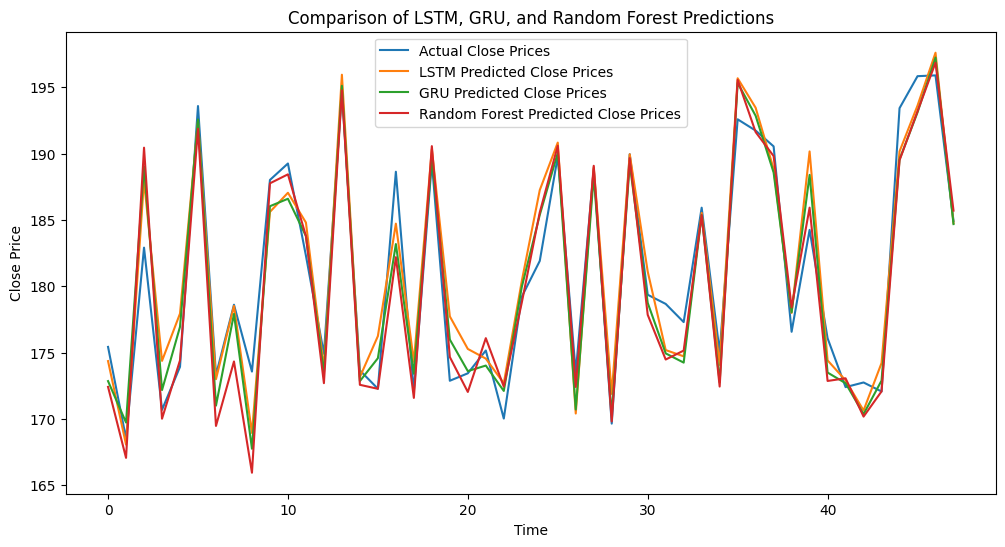

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

# Load your dataset
data = pd.read_csv("AAPL.csv")  # Replace with your actual CSV file

# Use only the 'close' column
data = data[['Close']]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Function to create sequences for LSTM and GRU models


def create_sequences(data, time_steps):
    x, y = [], []
    for i in range(len(data) - time_steps):
        x.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(x), np.array(y)


# Define the time steps and create sequences
time_steps = 10  # Adjust as needed
x, y = create_sequences(data_scaled, time_steps)

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

# Reshape the data for input to LSTM and GRU models
x_train_lstm = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_test_lstm = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)
x_train_gru = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_test_gru = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)

# Build the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(units=50, activation='relu',
               input_shape=(x_train_lstm.shape[1], 1)))
lstm_model.add(Dense(units=1))
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the LSTM model
lstm_model.fit(x_train_lstm, y_train, epochs=50, batch_size=32, verbose=0)

# Make predictions using the LSTM model
lstm_predictions = lstm_model.predict(x_test_lstm)
lstm_predictions = scaler.inverse_transform(lstm_predictions)
y_test_actual = scaler.inverse_transform(np.array([y_test]).reshape(-1, 1))

# Calculate RMSE for LSTM
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
print(f"LSTM Root Mean Squared Error (RMSE): {lstm_rmse}")

# Build the GRU model
gru_model = Sequential()
gru_model.add(GRU(units=50, activation='relu',
              input_shape=(x_train_gru.shape[1], 1)))
gru_model.add(Dense(units=1))
gru_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the GRU model
gru_model.fit(x_train_gru, y_train, epochs=50, batch_size=32, verbose=0)

# Make predictions using the GRU model
gru_predictions = gru_model.predict(x_test_gru)
gru_predictions = scaler.inverse_transform(gru_predictions)

# Calculate RMSE for GRU
gru_rmse = np.sqrt(mean_squared_error(y_test_actual, gru_predictions))
print(f"GRU Root Mean Squared Error (RMSE): {gru_rmse}")

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

# Make predictions using the Random Forest model
rf_predictions = rf_model.predict(x_test)
rf_predictions = rf_predictions.reshape(-1, 1)
rf_predictions = scaler.inverse_transform(rf_predictions)

# Calculate RMSE for Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_predictions))
print(f"Random Forest Root Mean Squared Error (RMSE): {rf_rmse}")

# Plot the actual vs predicted values for all models
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Close Prices')
plt.plot(lstm_predictions, label='LSTM Predicted Close Prices')
plt.plot(gru_predictions, label='GRU Predicted Close Prices')
plt.plot(rf_predictions, label='Random Forest Predicted Close Prices')
plt.legend()
plt.title('Comparison of LSTM, GRU, and Random Forest Predictions')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.show()

In [9]:
print(f"GRU Root Mean Squared Error (RMSE): {gru_rmse}")
print("is the very low mean Squared Error")

GRU Root Mean Squared Error (RMSE): 2.440249035280416
is the very low mean Squared Error


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import requests
from bs4 import BeautifulSoup as soup
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import datetime as dt
import nltk

# Download required nltk data
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')

def data(ticker):
    """Fetches stock data, trains a Random Forest model, and analyzes news sentiment."""
    today = dt.datetime.now().strftime('%Y-%m-%d')
    one_year_ago = (dt.datetime.now() - dt.timedelta(days=365)).strftime('%Y-%m-%d')
    print(f"Fetching stock data for {ticker} from {one_year_ago} to {today}...")
    
    # Fetch stock data
    stock = yf.download(ticker, start=one_year_ago, end=today, interval="1d")
    if stock.empty:
        print(f"Error: Could not fetch stock data for {ticker}")
        return
    
    stock.to_csv(f"{ticker}.csv")
    data = stock[['Close']]
    
    # Normalize the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data)
    
    # Create sequences
    def create_sequences(data, time_steps=10):
        x, y = [], []
        for i in range(len(data) - time_steps):
            x.append(data[i:(i + time_steps), 0])
            y.append(data[i + time_steps, 0])
        return np.array(x), np.array(y)
    
    time_steps = 10
    x, y = create_sequences(data_scaled, time_steps)
    
    # Split data
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    
    # Train Random Forest model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(x_train, y_train)
    
    # Predict future values
    future_sequence = data_scaled[-time_steps:].reshape(1, -1)
    num_predictions = 10
    future_predictions = []
    
    for _ in range(num_predictions):
        next_prediction = model.predict(future_sequence)[0]
        future_predictions.append(next_prediction)
        future_sequence = np.append(future_sequence[:, 1:], next_prediction).reshape(1, -1)
    
    # Inverse transform predictions
    future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))
    
    # Prepare dates for plotting
    actual_dates = stock.index
    future_dates = pd.date_range(start=actual_dates[-1], periods=num_predictions + 1)[1:]
    
    # Plot actual and predicted prices
    plt.figure(figsize=(12, 6))
    plt.plot(actual_dates, scaler.inverse_transform(data_scaled), label='Actual Close Prices', color='blue')
    plt.plot(future_dates, future_predictions, label='Predicted Future Prices', linestyle='dashed', color='red', marker='o')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.title(f"Stock Price Prediction for {ticker} using Random Forest")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.savefig(f"static/{ticker}.png")
    print("Stock price prediction completed. Now fetching news sentiment analysis...")

def newsdetails():
    """Fetches news data and performs sentiment analysis."""
    topic = "stock"
    site = f'https://news.google.com/rss/search?q={topic}'
    response = requests.get(site)
    if response.status_code != 200:
        print("Error fetching news data")
        return
    
    sp_page = soup(response.text, 'xml')
    news_titles = sp_page.find_all("title")
    news_dates = sp_page.find_all("pubDate")
    
    num_articles = min(len(news_titles), len(news_dates), 100)
    headlines = {"title": [], "publish_date": []}
    
    for k in range(num_articles):
        headlines["title"].append(news_titles[k].get_text())
        headlines["publish_date"].append(news_dates[k].get_text())
    
    df_news = pd.DataFrame(headlines)
    df_news.to_csv("news.csv", index=False)
    
    analyser = SentimentIntensityAnalyzer()
    df_news["VADER score"] = df_news["title"].apply(lambda x: analyser.polarity_scores(x)['compound'])
    
    def classify_sentiment(score):
        return 'positive' if score >= 0.1 else 'negative' if score <= -0.1 else 'neutral'
    
    df_news["sentiment"] = df_news["VADER score"].apply(classify_sentiment)
    df_news.to_csv("processed_news.csv", index=False)
    print("News sentiment analysis completed. Results saved in processed_news.csv.")

# Example usage:
# data("AMZN")

In [2]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
     -------------------------------------- 109.8/109.8 kB 1.3 MB/s eta 0:00:00
     ---------------------------------------- 3.0/3.0 MB 936.9 kB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for peewee: filename=peewee-3.17.9-py3-none-any.whl size=139127 sha256=305307325980a8a7c06b643d05b7bc0ce9835fd7c54a7ac54f2d562fd2a78ef6
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\af\56\87\585f494e912f4c33a5b6c475a48007d54e564ef1db92e24e84
Successfully built peewee
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[*********************100%***********************]  1 of 1 completed

Fetching stock data for AMZN from 2024-03-26 to 2025-03-26...


Stock price prediction completed. Now fetching news sentiment analysis...


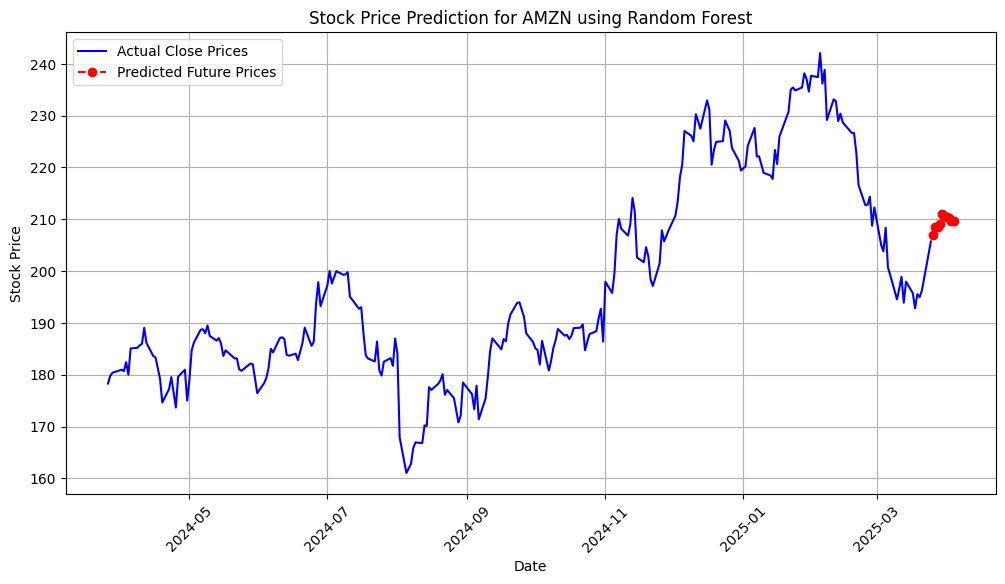

In [11]:
import yfinance as yf
import datetime as dt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ticker="AMZN"
today = dt.datetime.now().strftime('%Y-%m-%d')
one_year_ago = (dt.datetime.now() - dt.timedelta(days=365)).strftime('%Y-%m-%d')
print(f"Fetching stock data for {ticker} from {one_year_ago} to {today}...")
# Fetch stock data
stock = yf.download(ticker, start=one_year_ago, end=today, interval="1d")
if stock.empty:
    print(f"Error: Could not fetch stock data for {ticker}")
stock.to_csv(f"{ticker}.csv")
data = stock[['Close']]
    
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, time_steps=10):
    x, y = [], []
    for i in range(len(data) - time_steps):
        x.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(x), np.array(y)

time_steps = 10
x, y = create_sequences(data_scaled, time_steps)

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

# Predict future values
future_sequence = data_scaled[-time_steps:].reshape(1, -1)
num_predictions = 10
future_predictions = []

for _ in range(num_predictions):
    next_prediction = model.predict(future_sequence)[0]
    future_predictions.append(next_prediction)
    future_sequence = np.append(future_sequence[:, 1:], next_prediction).reshape(1, -1)

# Inverse transform predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Prepare dates for plotting
actual_dates = stock.index
future_dates = pd.date_range(start=actual_dates[-1], periods=num_predictions + 1)[1:]

# Plot actual and predicted prices
plt.figure(figsize=(12, 6))
plt.plot(actual_dates, scaler.inverse_transform(data_scaled), label='Actual Close Prices', color='blue')
plt.plot(future_dates, future_predictions, label='Predicted Future Prices', linestyle='dashed', color='red', marker='o')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title(f"Stock Price Prediction for {ticker} using Random Forest")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.savefig(f"{ticker}.png")
print("Stock price prediction completed. Now fetching news sentiment analysis...")